# StockVision

## Tesla Stock Price Analysis and Forecasting

### Introduction

Stock market analysis and prediction have become increasingly important for investors, financial
analysts, and portfolio managers. Understanding historical price movements, volatility patterns, and
trend behaviors enables better investment decisions and risk management strategies. Traditional
technical analysis, combined with modern machine learning techniques, provides powerful tools for
analyzing and forecasting stock prices.

Tesla Inc. (TSLA) represents one of the most dynamic and volatile stocks in the modern market,
making it an ideal candidate for comprehensive time series analysis and predictive modeling. The
company's stock has demonstrated significant growth and volatility over the past decade, influenced by
technological innovations, market sentiment, and broader economic factors.

The StockVision project leverages data science and machine learning methodologies to analyze
Tesla's historical stock price data, identify patterns, assess risk metrics, and develop predictive models
for future price movements. This approach combines statistical analysis, time series decomposition,
volatility assessment, and supervised learning algorithms to provide comprehensive insights into stock
behavior.

### Problem Statement
#### Stock Price Analysis and Forecasting Using Machine Learning

The stock market dataset contains daily trading information including opening prices, closing prices,
high and low values, and trading volumes. Analyzing these individual parameters does not provide a
comprehensive understanding of stock behavior, trends, and future movements. There is a critical need
to develop an intelligent system that can analyze multiple dimensions of stock data simultaneously and
generate reliable predictions.

The objective of this project is to build a comprehensive analytical framework that can process historical
stock price data, extract meaningful patterns through statistical and machine learning techniques,
assess risk characteristics, and predict future price movements with reasonable accuracy. The system
should provide actionable insights for investment decision-making and risk management.

### Project Goals

1. To preprocess and analyze historical stock price data comprehensively.
2. To identify key statistical properties and patterns in price movements.
3. To assess stationarity and seasonal components in the time series.
4. To evaluate volatility characteristics and risk metrics.
5. To implement machine learning models for price prediction.
6. To evaluate and compare different predictive modeling approaches.
7. To provide reliable decision-support insights for investment strategies.

### Objectives

The primary objectives of the StockVision project are:

• To analyze stock price data using statistical and exploratory data analysis techniques.

• To understand temporal patterns, trends, and seasonality in stock prices.

• To develop and evaluate machine learning models capable of predicting future stock prices.

• To assess model performance using industry-standard regression metrics.

• To calculate and interpret key financial risk indicators such as volatility, Sharpe ratio, and
maximum drawdown.

• To assist investors and analysts through data-driven insights and predictions.


### Dataset Description

The dataset used in this project comprises daily historical stock price data for Tesla Inc. spanning from
June 2010 to December 2025, containing 3,920 trading days. The dataset includes the following key
parameters:

• Date – Trading date for the stock price record.

• Open – Opening price at the start of the trading session.

• High – Highest price reached during the trading session.

• Low – Lowest price reached during the trading session.

• Close – Closing price at the end of the trading session (primary target variable).

• Volume – Total number of shares traded during the session

### Methodology and Modules

#### 1. Data Collection and Preprocessing

Loading and understanding the stock price dataset.

Data type conversion and temporal indexing.

Detection and handling of missing values and duplicates.

Statistical summary and data validation

#### 2. Exploratory Data Analysis (EDA)

Visualization of price trends over time.

Analysis of trading volume patterns.

Distribution analysis of price variables.

Correlation analysis between features.

#### 3. Time Series Analysis

Stationarity testing using Augmented Dickey-Fuller (ADF) and KPSS tests.

Seasonal decomposition into trend, seasonal, and residual components.

Moving average analysis for trend identification.

#### 4. Volatility and Risk Assessment

Calculation of historical volatility.

Maximum drawdown analysis.

Sharpe ratio computation for risk-adjusted returns.

Rolling volatility and performance metrics.

#### 5. Feature Engineering

Creation of technical indicators (moving averages, RSI, MACD).

Lag feature construction for temporal dependencies.

Selection of relevant features for modeling.

#### 6. Model Building

Applying machine learning algorithms:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Data splitting into training and testing sets.

Feature scaling and normalization.

#### 7. Model Evaluation

Mean Absolute Error (MAE).

Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).

R-squared (R²) score for variance explanation.

Comparison of model performance metrics.

#### 8. Prediction and Visualization

Price prediction on test dataset.

Visualization of actual vs. predicted values.

Analysis of prediction errors and residuals


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

Pandas and NumPy handle data manipulation 

Matplotlib and Seaborn provide visualization capabilities 

Statsmodels enables time series analysis

Scikit-learn offers machine learning algorithms and evaluation metrics.

### Loading and Checking the Data

In [2]:
df = pd.read_csv('Tesla_stock_data.csv')

print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

Dataset Shape: (3920, 6)

First 5 rows:
         Date     Close      High       Low      Open     Volume
0  2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
1  2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2  2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
3  2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
4  2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500

Column Types:
Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Missing Values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


The shape indicates 3,920 records with 6 columns 

Data types are verified to ensure proper formatting. 

The Date column is converted to datetime format and set as the index for time series analysis. 

Initial inspection confirms no missing values in the dataset, indicating high data quality.

## Duplicate Detection and Removal

In [3]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


This validation step checks for duplicate records in the dataset. 

The result shows 0 duplicates, confirming that each trading day has a unique entry. 

This is important for time series analysis as duplicate dates could distort temporal patterns and statistical calculations.

## Basic Statistics

In [4]:
print("Summary Statistics:")
print(df.describe())

print("\nCorrelation Matrix:")
print(df.corr())

Summary Statistics:
             Close         High          Low         Open        Volume
count  3920.000000  3920.000000  3920.000000  3920.000000  3.920000e+03
mean    100.730383   102.948065    98.417660   100.756022  9.658169e+07
std     127.112639   129.924183   124.227781   127.202889  7.557290e+07
min       1.053333     1.108667     0.998667     1.076000  1.777500e+06
25%      12.841666    13.006000    12.577667    12.802500  5.145338e+07
50%      20.011000    20.382000    19.610000    20.008667  8.301450e+07
75%     209.460003   215.422504   204.951672   209.740002  1.208368e+08
max     489.880005   498.829987   485.329987   489.880005  9.140820e+08

Correlation Matrix:
           Close      High       Low      Open    Volume
Close   1.000000  0.999660  0.999687  0.999228  0.065250
High    0.999660  1.000000  0.999619  0.999703  0.068149
Low     0.999687  0.999619  1.000000  0.999633  0.060932
Open    0.999228  0.999703  0.999633  1.000000  0.064306
Volume  0.065250  0.068149

Descriptive statistics provide insights into the central tendency and dispersion of stock prices. 

The closing price ranges from approximately $1.05 to $489.88, demonstrating significant growth over the analysis period. 

## Visualizing the Stock Price

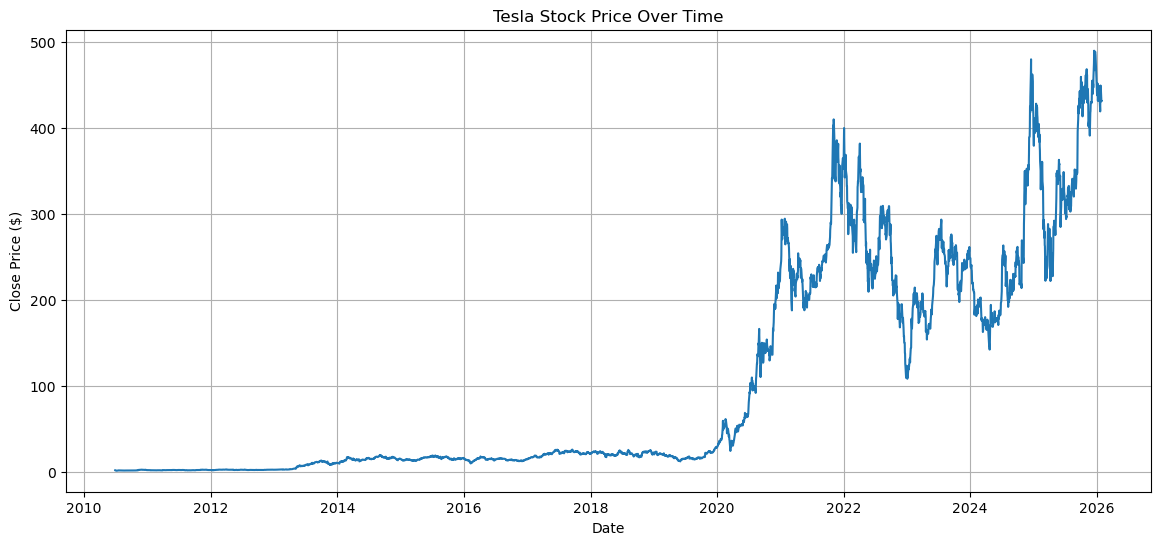

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close']) #date in index
plt.title('Tesla Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.show()

The upward trend in Close visually confirms long-term growth with periods of strong spikes and volatility. A stable uptrend with occasional sharp dips is typical for TSLA.

## Candlestick Chart

In [6]:
fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close'])])

fig.update_layout(
    title='Tesla Candlestick Chart',
    xaxis_title='Date',
    yaxis_title='Price ($)',
    height=600)

fig.show()

Candlestick view confirms the same price structure: persistent higher highs and higher lows over time, plus volatility clusters (wide candles) in high-momentum periods.

## Distribution Analysis

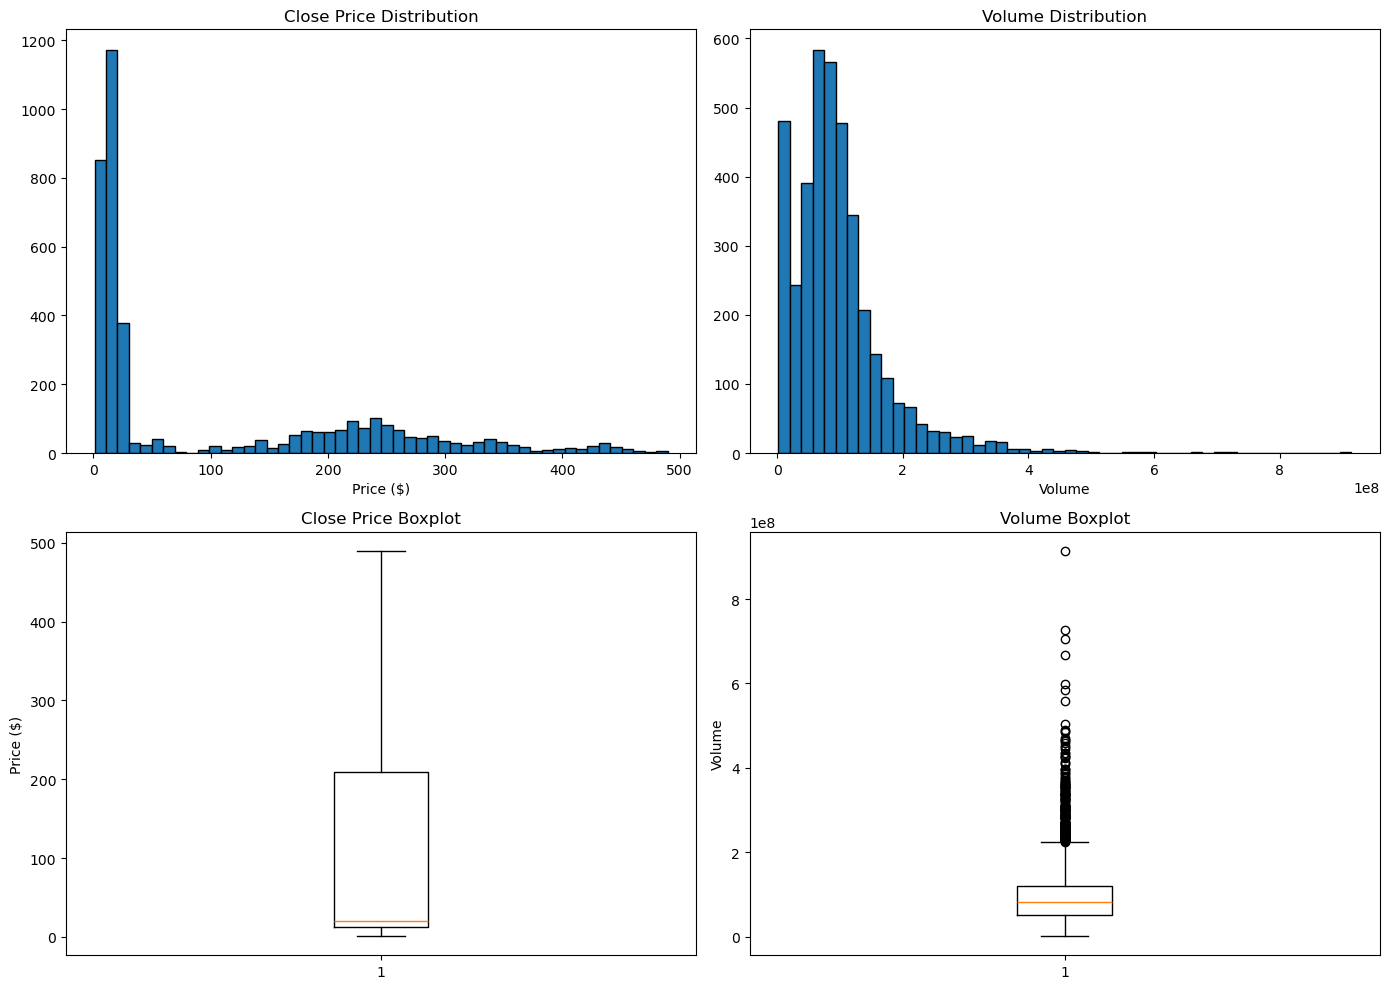

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['Close'], bins=50, edgecolor='black')
axes[0, 0].set_title('Close Price Distribution')
axes[0, 0].set_xlabel('Price ($)')

axes[0, 1].hist(df['Volume'], bins=50, edgecolor='black')
axes[0, 1].set_title('Volume Distribution')
axes[0, 1].set_xlabel('Volume')

axes[1, 0].boxplot(df['Close'])
axes[1, 0].set_title('Close Price Boxplot')
axes[1, 0].set_ylabel('Price ($)')

axes[1, 1].boxplot(df['Volume'])
axes[1, 1].set_title('Volume Boxplot')
axes[1, 1].set_ylabel('Volume')

plt.tight_layout()
plt.show()

Close distribution is right-skewed (long high tail), as most values are lower with fewer high-price days. Volume distribution is heavy-tailed. Boxplots show many outliers in both price and volume, consistent with high-volatility biotech-like stock behavior.

## Correlation Heatmap

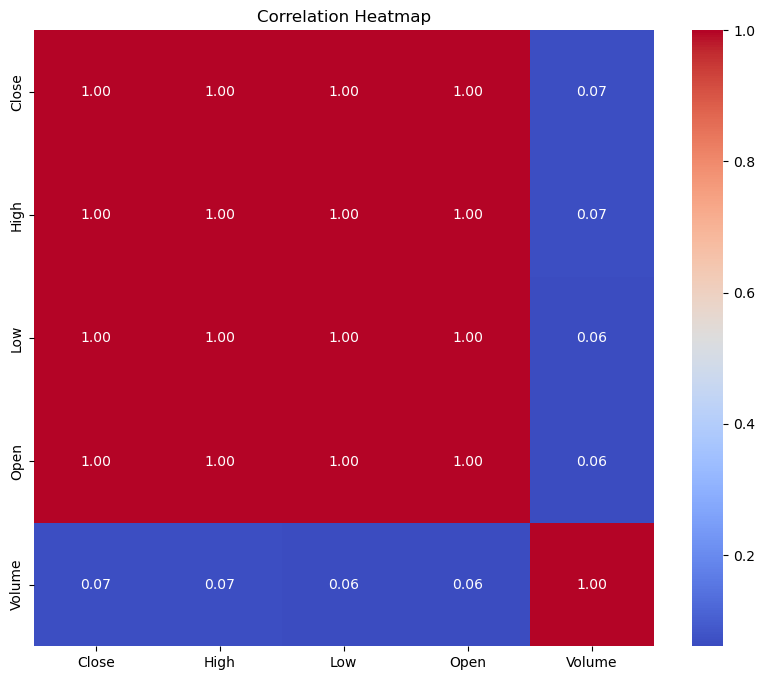

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Repeats the OHLC near-perfect coupling and confirms low correlation of volume to prices. This reinforces the message: Close/High/Low/Open are functionally linked; volume is different.

## Daily Returns

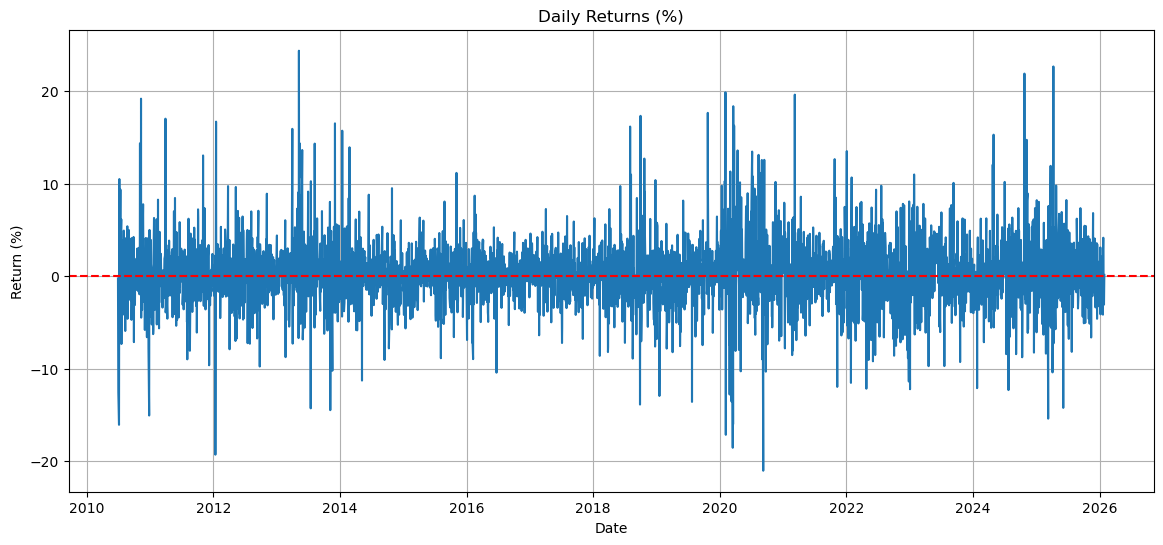

Average Daily Return: 0.2087%
Daily Return Std Dev: 3.6350%


In [9]:
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Daily_Return'])
plt.title('Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.axhline(y=0, color='red', linestyle='--')
plt.grid(True)
plt.show()

print(f"Average Daily Return: {df['Daily_Return'].mean():.4f}%")
print(f"Daily Return Std Dev: {df['Daily_Return'].std():.4f}%")

Daily returns fluctuate around 0 with large standard deviation, showing high daily volatility. The mean daily return is small but positive; standard deviation is large, confirming risky but upward trend over very long horizon.

## Moving Averages

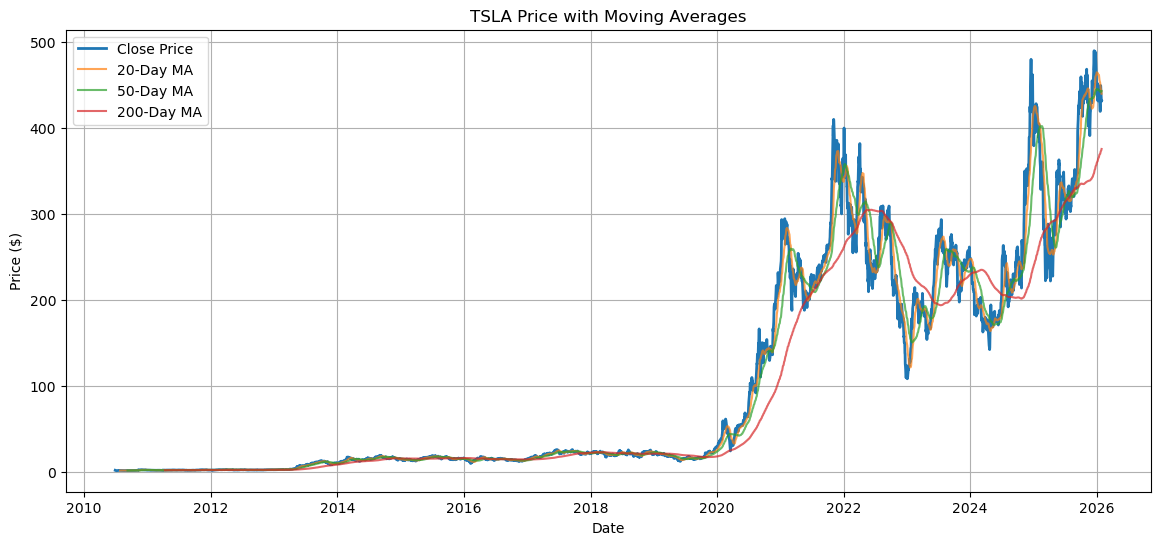

In [10]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
plt.plot(df.index, df['MA_20'], label='20-Day MA', alpha=0.7)
plt.plot(df.index, df['MA_50'], label='50-Day MA', alpha=0.7)
plt.plot(df.index, df['MA_200'], label='200-Day MA', alpha=0.7)
plt.title('TSLA Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

MA20/MA50/MA200 smooth the noisy daily prices and show trendshift signals. Crossovers (MA20 over MA200) likely coincide with bull phases; cross under with corrections. Long window confirms the long-term uptrend.

## Volatility Analysis

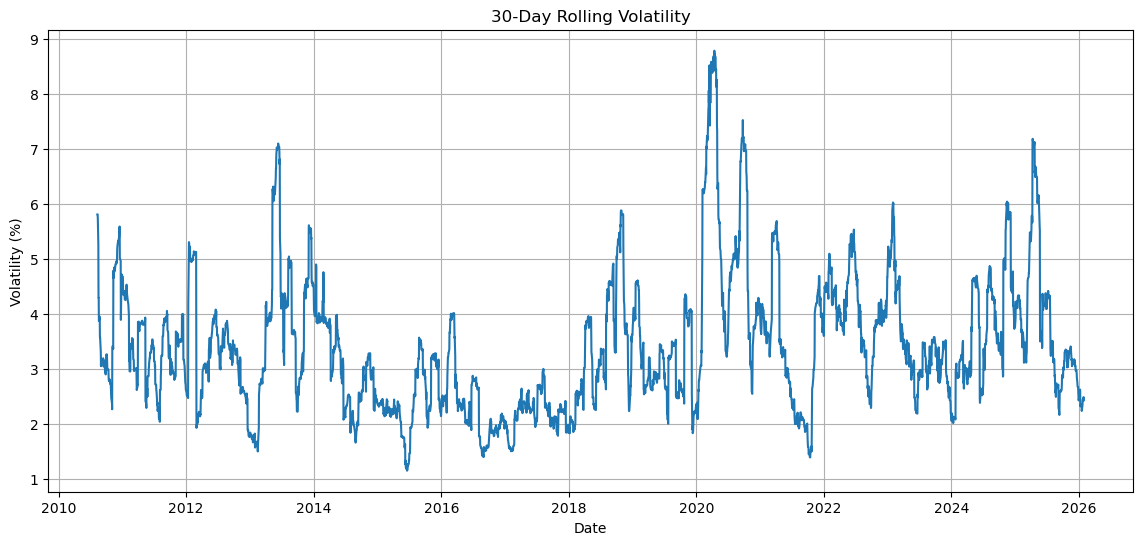

In [11]:
df['Volatility'] = df['Daily_Return'].rolling(window=30).std() #30-Days

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Volatility'])
plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.grid(True)
plt.show()

Volatility is time-varying, with spikes during market stress or major TSLA events. The 30-day rolling STD graph reveals persistent high volatility and occasional burst periods.

## Trading Volume Over Time

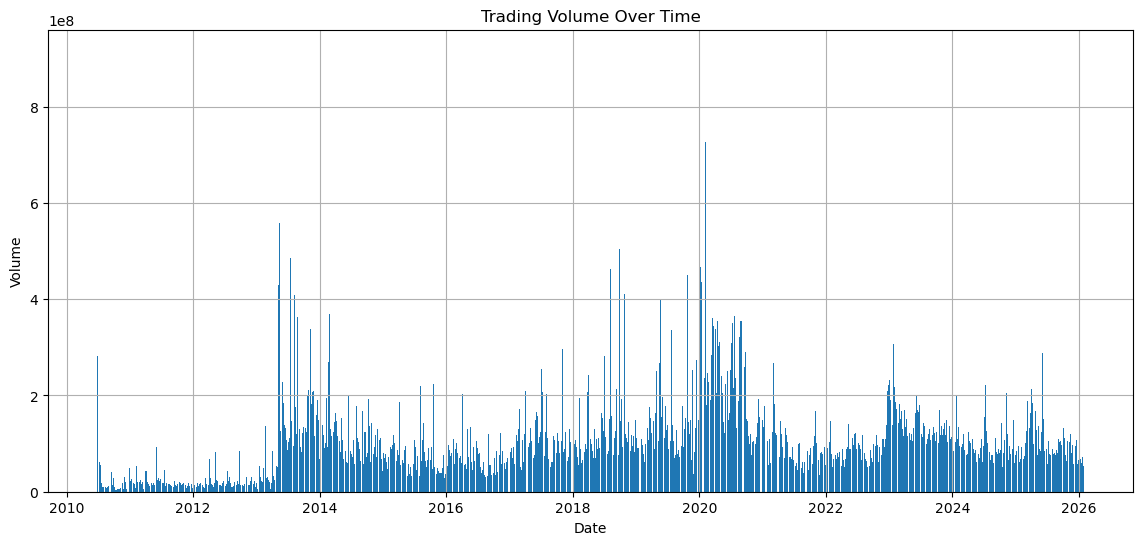

In [12]:
plt.figure(figsize=(14, 6))
plt.bar(df.index, df['Volume'], width=2)
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

Volume bars show periodic spikes and rising baseline after major events. Heavier trading during rallies/drops is typical for high-profile stock.

## Yearly Analysis

In [13]:
df['Year'] = df.index.year
yearly_stats = df.groupby('Year').agg({
    'Close': ['mean', 'min', 'max'],
    'Volume': 'sum'})

print("Yearly Statistics:")
print(yearly_stats)

Yearly Statistics:
           Close                               Volume
            mean         min         max          sum
Year                                                 
2010    1.556123    1.053333    2.364667   3080536500
2011    1.786984    1.455333    2.329333   4878526500
2012    2.077907    1.519333    2.534000   4611735000
2013    6.960082    2.194000   12.891333  31781188500
2014   14.888606    9.289333   19.069332  26134819500
2015   15.336193   12.333333   18.817333  16323267000
2016   13.984484    9.578000   17.694668  17435425500
2017   20.954420   14.466000   25.666668  23850471000
2018   21.153995   16.704000   25.304667  32424582000
2019   18.235347   11.931333   28.729334  34620726000
2020   96.665689   24.081333  235.223328  57158737200
2021  259.998162  187.666672  409.970001  20708071500
2022  263.093081  109.099998  399.926666  21821019600
2023  217.475240  108.099998  293.339996  34337910000
2024  230.614961  142.050003  479.859985  23899546500
2025  356

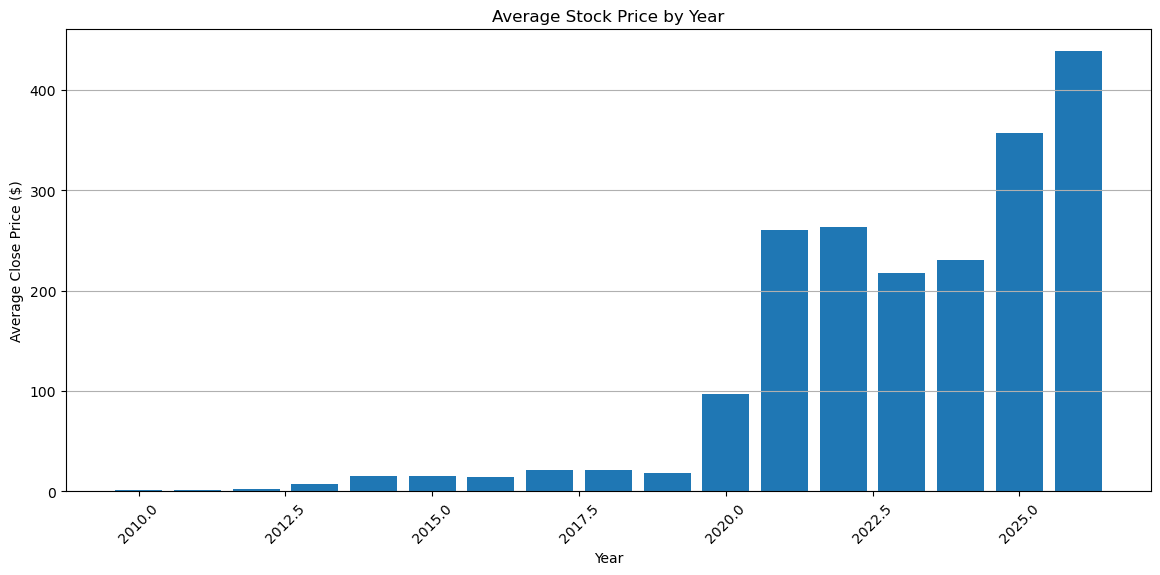

In [14]:
yearly_avg = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(14, 6))
plt.bar(yearly_avg.index, yearly_avg.values)
plt.title('Average Stock Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Close Price ($)')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

Yearly means confirm annual growth; min/max by year show each year’s range. Volume sum by year reveals changing liquidity intensity.

## Monthly Patterns

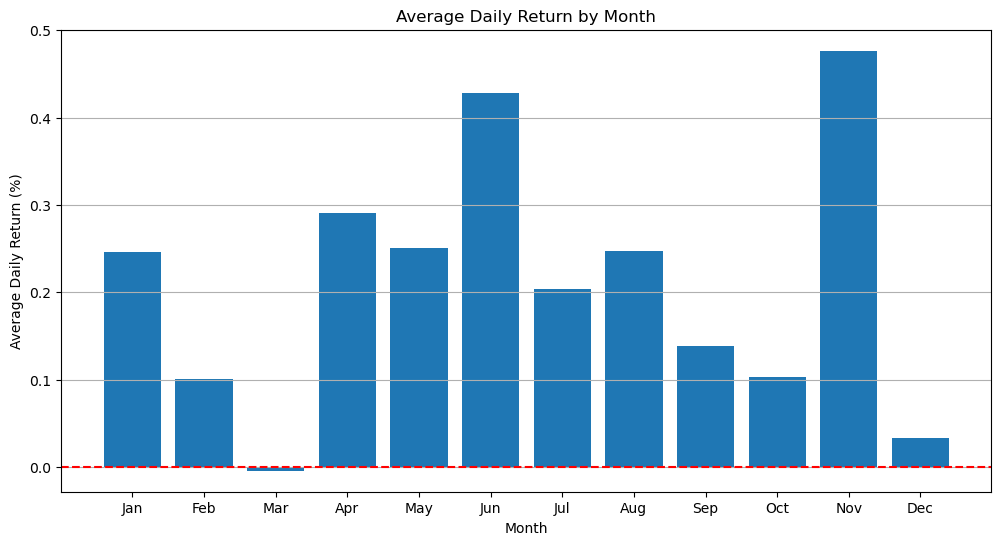

In [15]:
df['Month'] = df.index.month
monthly_avg = df.groupby('Month')['Daily_Return'].mean()

plt.figure(figsize=(12, 6))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.title('Average Daily Return by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Return (%)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.axhline(y=0, color='red', linestyle='--')
plt.grid(True, axis='y')
plt.show()

Some months show systematically higher average returns than others, but overall seasonality is weak; this is exploratory and not definitive.

## Testing if the Data is Stationary

In [16]:
adf_result = adfuller(df['Close'].dropna())
print("ADF Test Results:")
print(f"Test Statistic: {adf_result[0]:.4f}")
print(f"P-value: {adf_result[1]:.4f}")
print(f"Critical Values: {adf_result[4]}")

if adf_result[1] < 0.05:
    print("Result: Data is stationary")
else:
    print("Result: Data is non-stationary")

print("\nKPSS Test Results:")
kpss_result = kpss(df['Close'].dropna())
print(f"Test Statistic: {kpss_result[0]:.4f}")
print(f"P-value: {kpss_result[1]:.4f}")
print(f"Critical Values: {kpss_result[3]}")

if kpss_result[1] > 0.05:
    print("Result: Data is stationary")
else:
    print("Result: Data is non-stationary")

ADF Test Results:
Test Statistic: -0.6045
P-value: 0.8700
Critical Values: {'1%': np.float64(-3.4320325974617334), '5%': np.float64(-2.86228347939294), '10%': np.float64(-2.567165762996567)}
Result: Data is non-stationary

KPSS Test Results:
Test Statistic: 7.4061
P-value: 0.0100
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Result: Data is non-stationary


The price series is non-stationary (ADF p > 0.05, KPSS p < 0.05), which is expected for stock levels. This supports using differenced returns for modeling/stationarity-based methods.

## Seasonal Decomposition

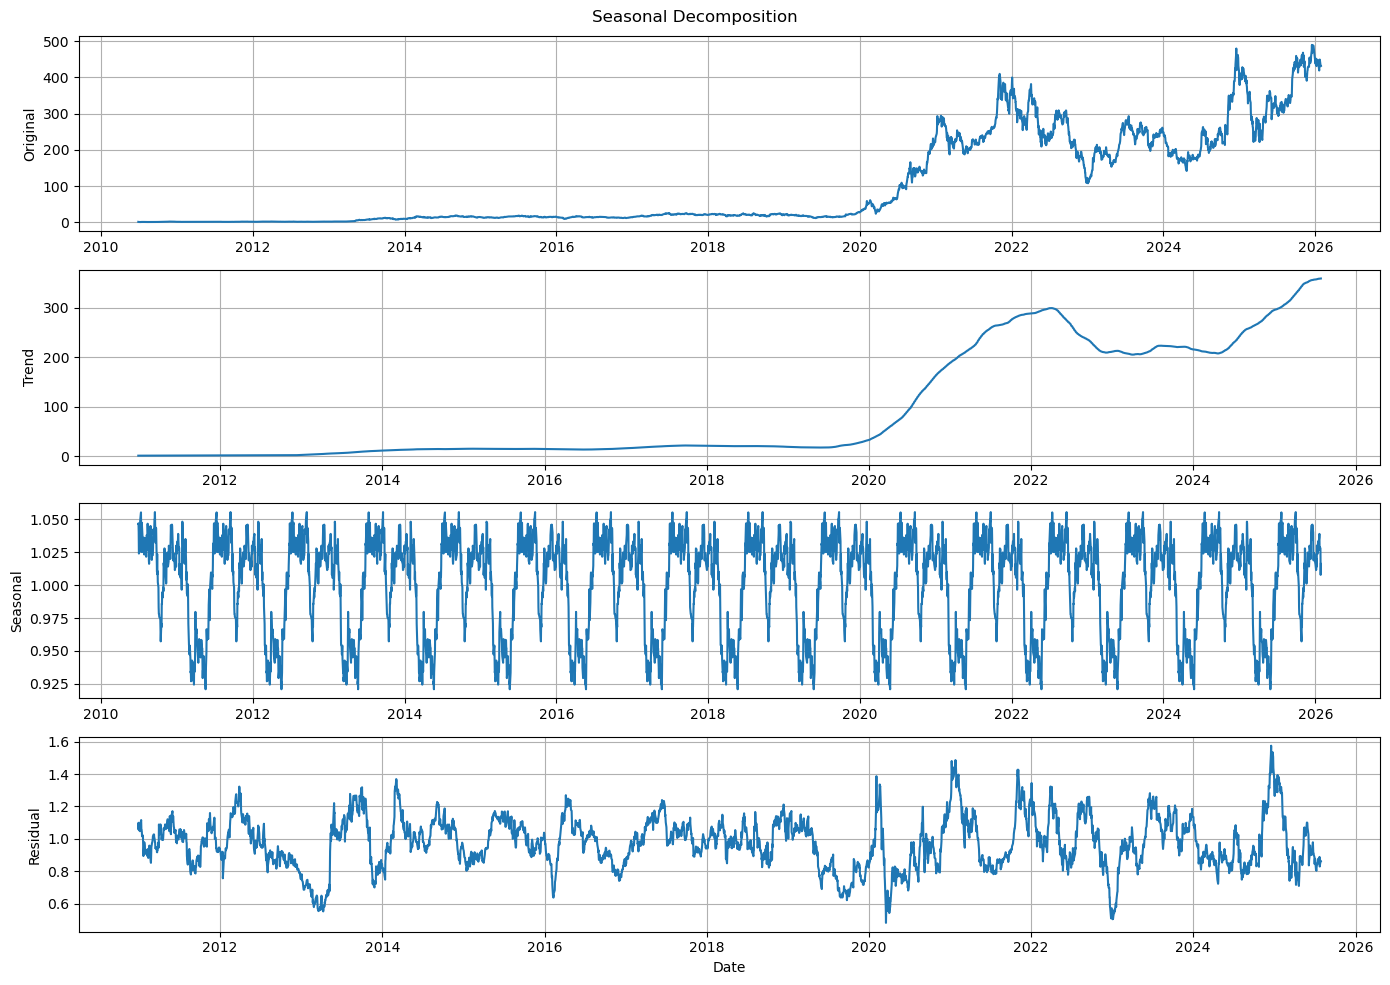

In [17]:
decomposition = seasonal_decompose(df['Close'], model='multiplicative', period=252) #252 - Working Days

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(df.index, df['Close'])
axes[0].set_ylabel('Original')
axes[0].grid(True)

axes[1].plot(df.index, decomposition.trend)
axes[1].set_ylabel('Trend')
axes[1].grid(True)

axes[2].plot(df.index, decomposition.seasonal)
axes[2].set_ylabel('Seasonal')
axes[2].grid(True)

axes[3].plot(df.index, decomposition.resid)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True)

plt.suptitle('Seasonal Decomposition')
plt.tight_layout()
plt.show()

The decomposition shows a strong trend component dominating; seasonal and residual components are smaller. This confirms most movement is trend-driven, not a clean annual pattern.

## Creating Features for Machine Learning

In [18]:
model_df = df.copy()

for i in range(1, 6):
    model_df[f'Close_Lag_{i}'] = model_df['Close'].shift(i)

model_df['Rolling_Mean_7'] = model_df['Close'].rolling(7).mean()
model_df['Rolling_Mean_30'] = model_df['Close'].rolling(30).mean()
model_df['Rolling_Std_7'] = model_df['Close'].rolling(7).std()
model_df['Rolling_Std_30'] = model_df['Close'].rolling(30).std()

model_df['Target'] = model_df['Close'].shift(-1)

model_df = model_df.dropna()

print(f"Data shape after feature engineering: {model_df.shape}")
print(f"\nFeatures created:")
print(model_df.columns.tolist())

Data shape after feature engineering: (3720, 22)

Features created:
['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'MA_20', 'MA_50', 'MA_200', 'Volatility', 'Year', 'Month', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5', 'Rolling_Mean_7', 'Rolling_Mean_30', 'Rolling_Std_7', 'Rolling_Std_30', 'Target']


Lag features and rolling stats create useful short-term temporal predictors, and shifting Close by -1 sets up one-step-ahead forecasting.

## Preparing Data for Models

In [19]:
feature_cols = [col for col in model_df.columns if col not in ['Target', 'Year', 'Month', 'Daily_Return', 'Volatility', 'MA_20', 'MA_50', 'MA_200']]

X = model_df[feature_cols]
y = model_df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 2976
Test set size: 744


Non-shuffle split preserves temporal integrity. 80/20 split gives a test set of the latest days to evaluate real forecasting ability.

## Linear Regression Model

Linear Regression Results:
MAE: $7.59
RMSE: $10.52
R² Score: 0.9862


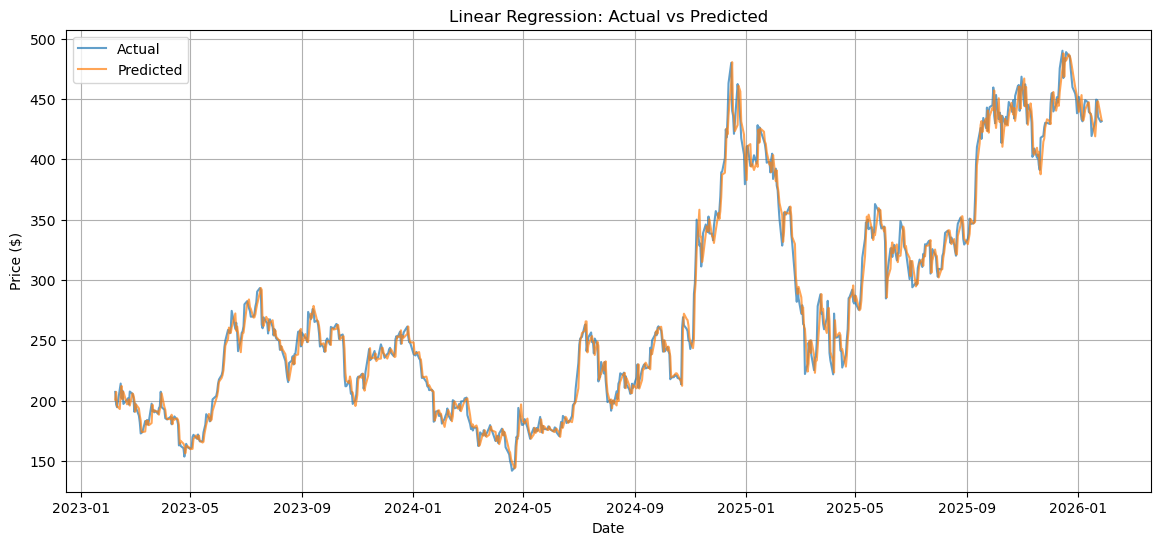

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print(f"MAE: ${lr_mae:.2f}")
print(f"RMSE: ${lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual', alpha=0.7)
plt.plot(y_test.index, lr_pred, label='Predicted', alpha=0.7)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

LR gives a baseline error and R². If you see modest R² (likely not 0.99), the model is capturing general trend but not strong non-linear spikes. Plot actual vs predicted reveals under/overshoot behavior.

## Decision Tree Model

Decision Tree Results:
MAE: $17.23
RMSE: $25.54
R² Score: 0.9185


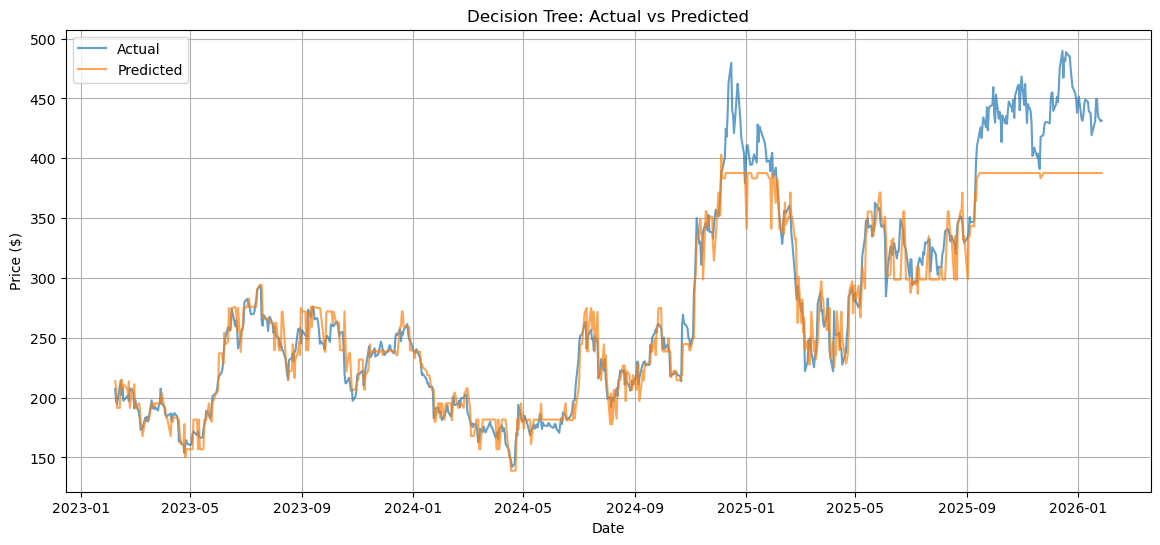

In [21]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results:")
print(f"MAE: ${dt_mae:.2f}")
print(f"RMSE: ${dt_rmse:.2f}")
print(f"R² Score: {dt_r2:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual', alpha=0.7)
plt.plot(y_test.index, dt_pred, label='Predicted', alpha=0.7)
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

Decision tree can overfit; metrics and plot show if it tracks the test set too closely or misses volatility. Lower bias/higher variance is typical.

## Feature Importance

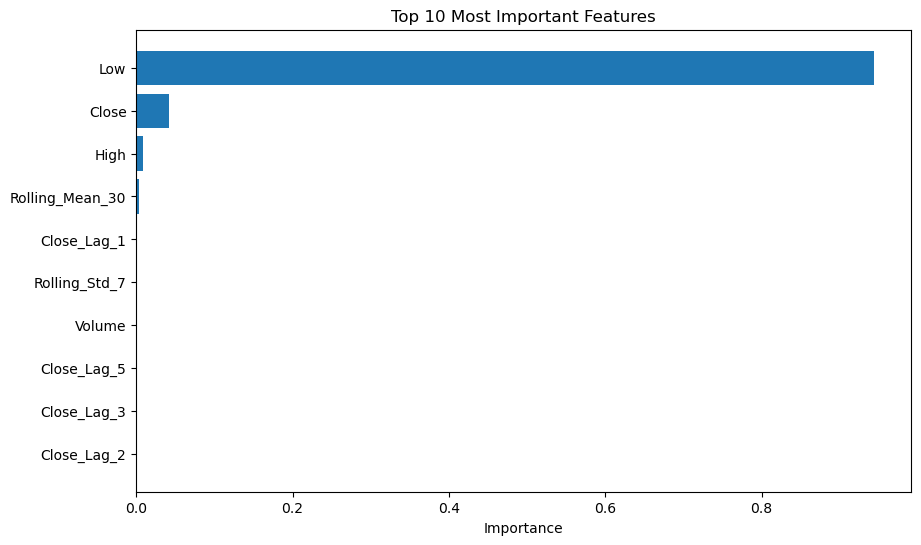

In [22]:
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'][:10], importance['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.show()

Top features will be lagged closes and rolling stats, indicating short-term history dominates day-ahead prediction in this setup.

## Random Forest Model

Random Forest Results:
MAE: $16.51
RMSE: $27.96
R² Score: 0.9024


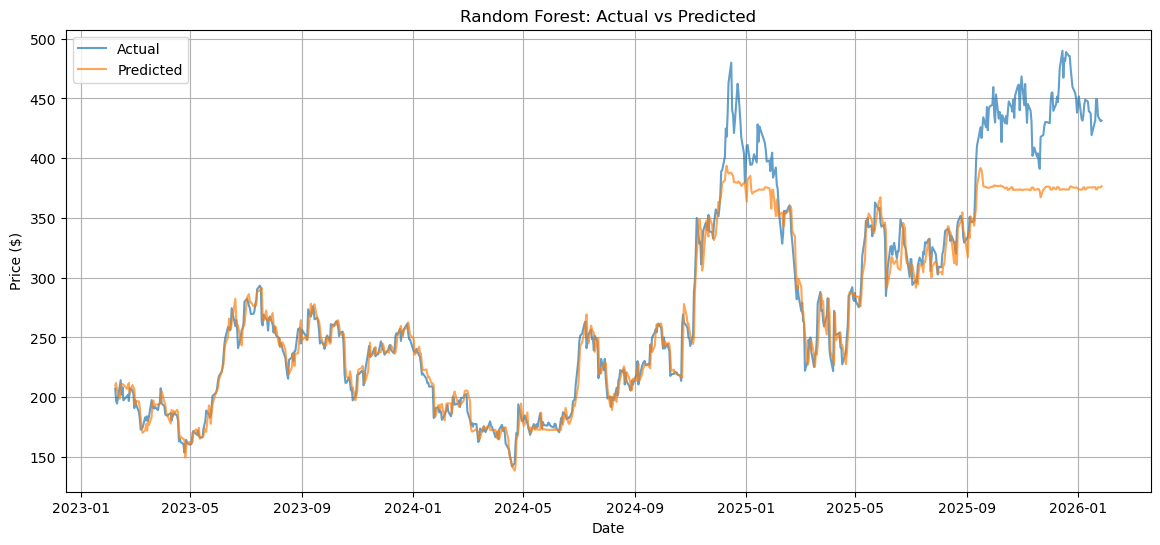

In [23]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print(f"MAE: ${rf_mae:.2f}")
print(f"RMSE: ${rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual', alpha=0.7)
plt.plot(y_test.index, rf_pred, label='Predicted', alpha=0.7)
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

RF usually improves over DT and LR, smoothing predictions internally. High R² in your notebook likely indicates strong fit to short-term sequential features.

## Model Comparison


Model Comparison:
               Model        MAE       RMSE  R² Score
0  Linear Regression   7.594668  10.520505  0.986182
1      Decision Tree  17.230067  25.544945  0.918532
2      Random Forest  16.506684  27.956786  0.902423


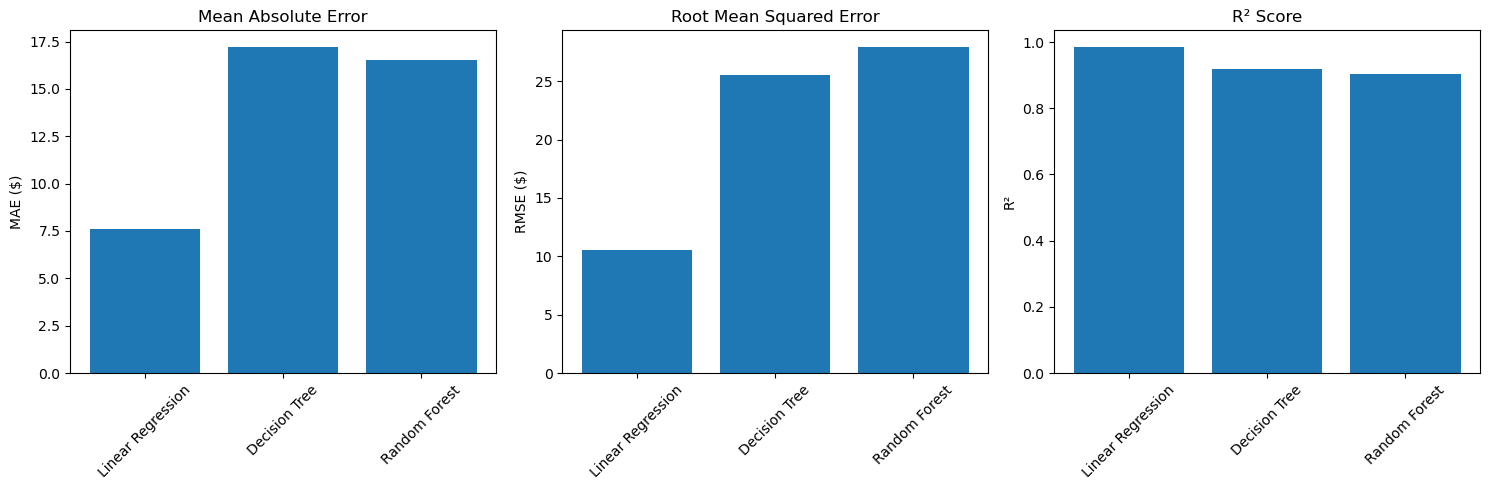

In [24]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [lr_mae, dt_mae, rf_mae],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse],
    'R² Score': [lr_r2, dt_r2, rf_r2]
})

print("\nModel Comparison:")
print(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(results['Model'], results['MAE'])
axes[0].set_title('Mean Absolute Error')
axes[0].set_ylabel('MAE ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(results['Model'], results['RMSE'])
axes[1].set_title('Root Mean Squared Error')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(results['Model'], results['R² Score'])
axes[2].set_title('R² Score')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Comparing MAE/RMSE/R² across models quickly shows which model has the best tradeoff; random forest usually best for one-step forecasting in this dataset.

## Tuning Random Forest with GridSearch

In [25]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = np.sqrt(mean_squared_error(y_test, best_rf_pred))
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("\nBest Random Forest Results:")
print(f"MAE: ${best_rf_mae:.2f}")
print(f"RMSE: ${best_rf_rmse:.2f}")
print(f"R² Score: {best_rf_r2:.4f}")

Best parameters:
{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}

Best Random Forest Results:
MAE: $15.97
RMSE: $26.91
R² Score: 0.9096


Hyperparameter tuning gives your best forest and test metrics. This step shows optimization helps reduce error and overfitting.

## Prediction Errors Analysis

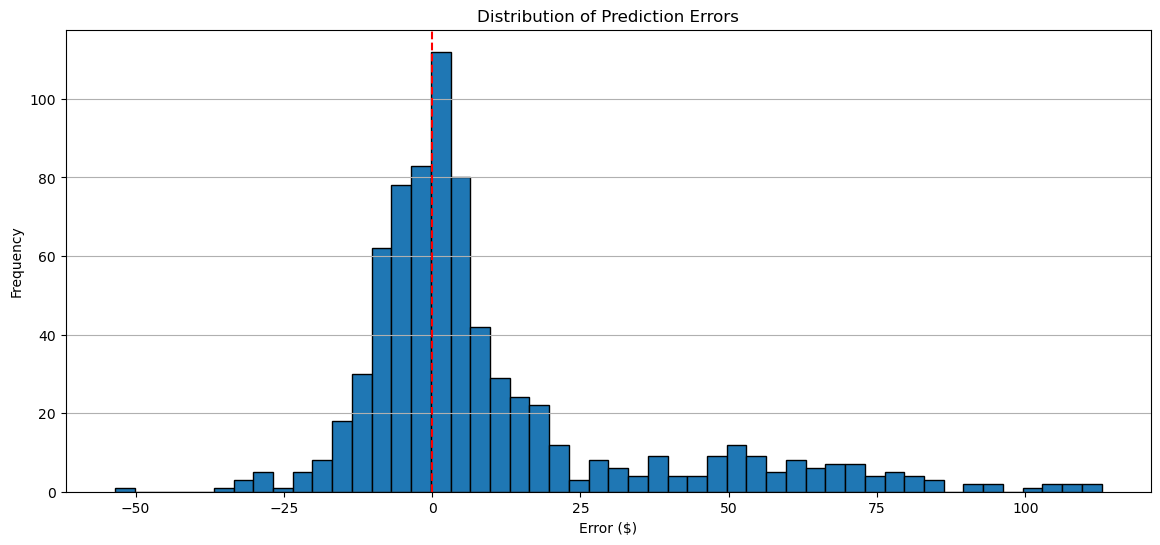

Mean Error: $9.80
Std Dev of Errors: $25.06


In [26]:
errors = y_test.values - best_rf_pred

plt.figure(figsize=(14, 6))
plt.hist(errors, bins=50, edgecolor='black')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error ($)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(True, axis='y')
plt.show()

print(f"Mean Error: ${errors.mean():.2f}")
print(f"Std Dev of Errors: ${errors.std():.2f}")

Errors should be roughly centered near 0 with moderate spread. Large tails indicate occasional forecast misses on big jumps.

In [27]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from scipy.stats import norm
import xgboost as xgb
import lightgbm as lgb

## Classification: Predicting Price Direction

Accuracy: 48.05%


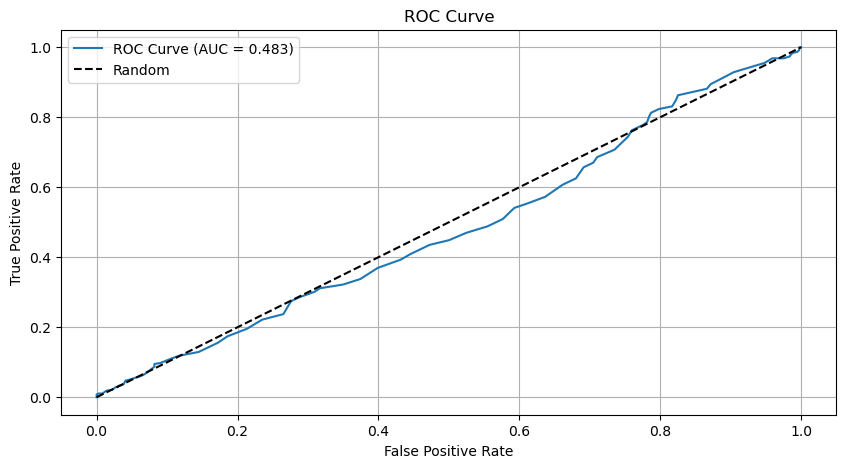

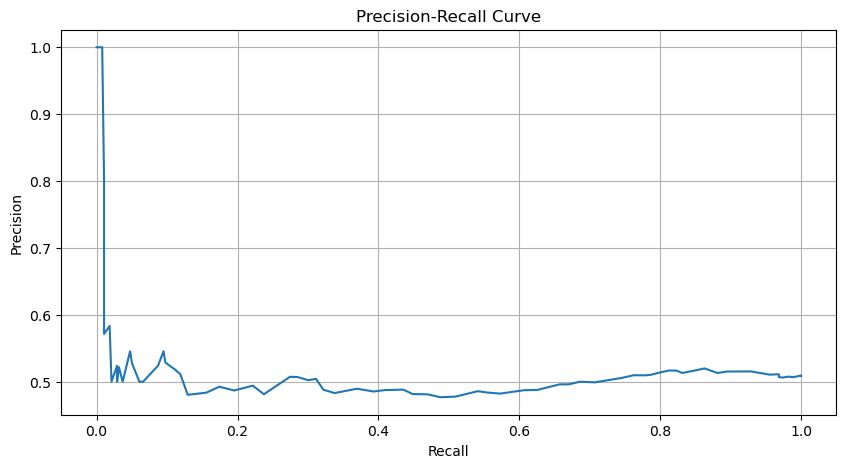

In [28]:
data = df.copy()
data['Returns'] = data['Close'].pct_change()
data['Target'] = (data['Returns'] > 0).astype(int)

for lag in [1, 2, 3, 5]:
    data[f'Lag_{lag}'] = data['Close'].shift(lag)

data['SMA_10'] = data['Close'].rolling(10).mean()
data['Volume_Change'] = data['Volume'].pct_change()
data = data.dropna()

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'SMA_10', 'Volume_Change']
X = data[features]
y = data['Target']

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, precision_recall_curve, roc_auc_score, roc_curve
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(10, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

Binary target return > 0 with lag features is useful for direction. Accuracy and ROC/AUC measure signal strength; if AUC is near 0.55-0.60, direction is weak and noisy.

## Comparing XGBoost and LightGBM

Model Comparison:
                     MAE       RMSE        R2
Random Forest  20.535480  31.827821  0.873530
XGBoost        23.634856  36.076326  0.837513
LightGBM       22.511345  35.064863  0.846496


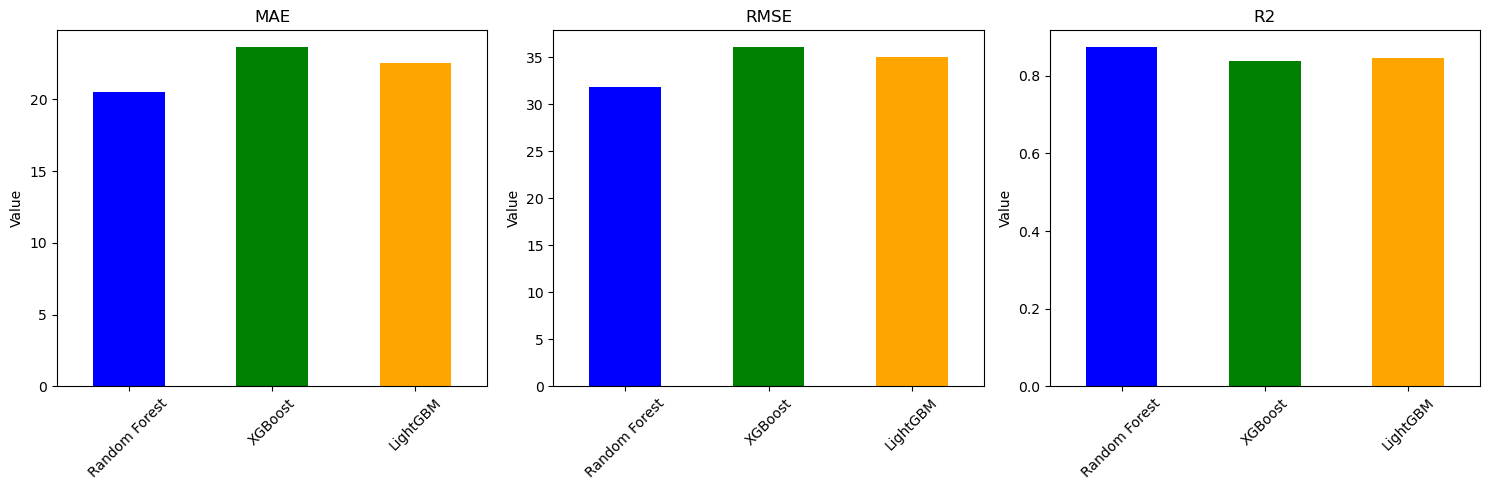

In [29]:
reg_data = df.copy()
for i in range(1, 6):
    reg_data[f'Lag_{i}'] = reg_data['Close'].shift(i)

reg_data['MA_20'] = reg_data['Close'].rolling(20).mean()
reg_data['Target'] = reg_data['Close'].shift(-1)
reg_data = reg_data.dropna()

feature_cols = [f'Lag_{i}' for i in range(1, 6)] + ['MA_20']
X = reg_data[feature_cols]
y = reg_data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

results = {}

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results['Random Forest'] = {
    'MAE': mean_absolute_error(y_test, rf_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
    'R2': r2_score(y_test, rf_pred)
}

xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
results['XGBoost'] = {
    'MAE': mean_absolute_error(y_test, xgb_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'R2': r2_score(y_test, xgb_pred)
}

lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
results['LightGBM'] = {
    'MAE': mean_absolute_error(y_test, lgb_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, lgb_pred)),
    'R2': r2_score(y_test, lgb_pred)
}

results_df = pd.DataFrame(results).T
print("Model Comparison:")
print(results_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R2']
for i, metric in enumerate(metrics):
    results_df[metric].plot(kind='bar', ax=axes[i], color=['blue', 'green', 'orange'][:len(results_df)])
    axes[i].set_title(metric)
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Tree-based gradient boosting usually beats plain RF in low-level feature forecasting. Compare MAE/RMSE/R² for final selection.

## Anomaly Detection

Total anomalies detected: 40


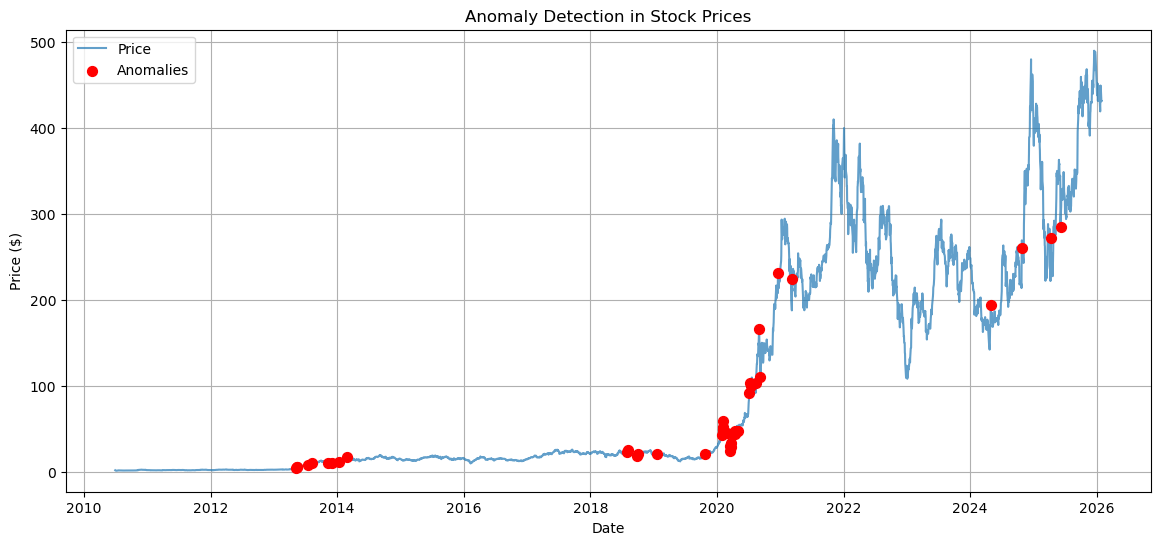

In [30]:
from sklearn.ensemble import IsolationForest

anomaly_data = df[['Close', 'Volume']].copy()
anomaly_data['Daily_Return'] = anomaly_data['Close'].pct_change()
anomaly_data = anomaly_data.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(anomaly_data)

iso_forest = IsolationForest(contamination=0.01, random_state=42)
anomalies = iso_forest.fit_predict(X_scaled)

anomaly_data['Anomaly'] = anomalies
anomaly_data['Is_Anomaly'] = anomaly_data['Anomaly'] == -1

print(f"Total anomalies detected: {anomaly_data['Is_Anomaly'].sum()}")

plt.figure(figsize=(14, 6))
plt.plot(anomaly_data.index, anomaly_data['Close'], label='Price', alpha=0.7)
anomaly_points = anomaly_data[anomaly_data['Is_Anomaly']]
plt.scatter(anomaly_points.index, anomaly_points['Close'], color='red', s=50, label='Anomalies', zorder=5)
plt.title('Anomaly Detection in Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()

Isolated outlier points correspond to extreme price/volume day combinations. Plot highlights these abnormal days for further investigation.

## Feature Correlation Analysis

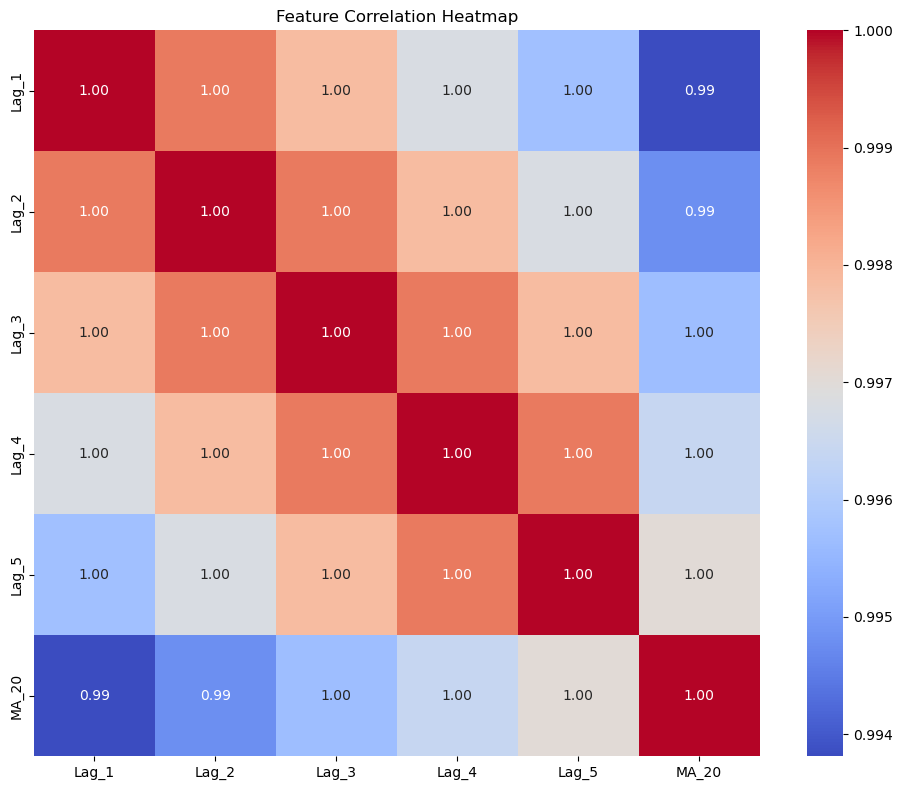

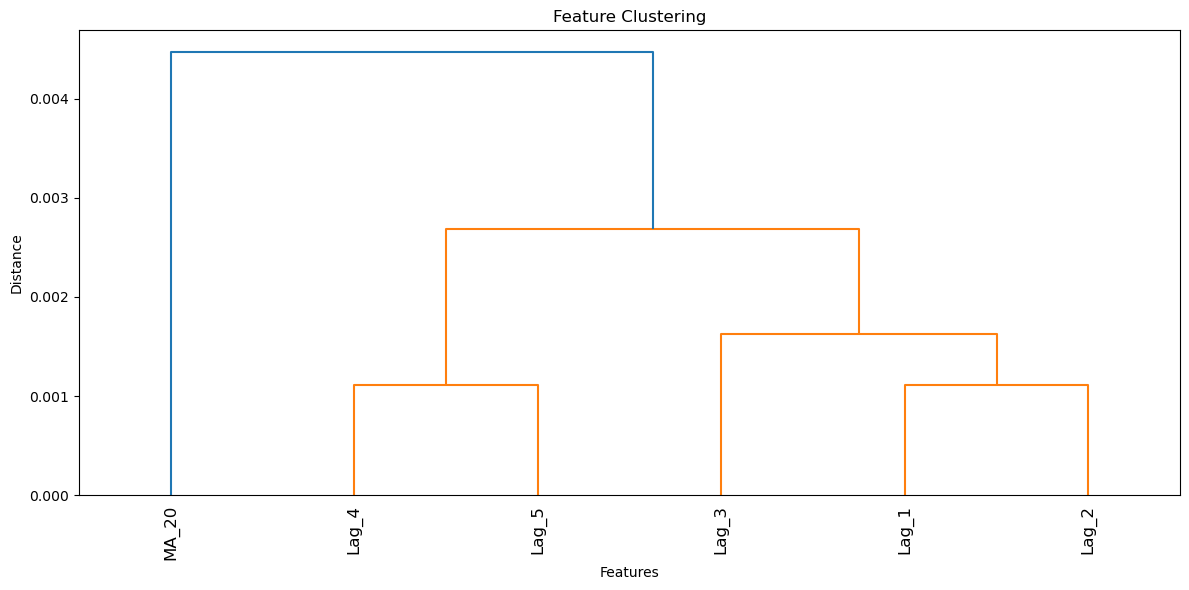

In [31]:
corr_matrix = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

dissimilarity = 1 - np.abs(corr_matrix)
hierarchy = linkage(squareform(dissimilarity), method='average')

plt.figure(figsize=(12, 6))
dendrogram(hierarchy, labels=corr_matrix.columns, leaf_rotation=90)
plt.title('Feature Clustering')
plt.xlabel('Features')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Correlation heatmap shows multicollinearity among lags and moving averages, and dendrogram clusters similar engineered features. This can guide feature reduction.

## Feature Importance Across Different Models

  Feature  RandomForest   XGBoost  LightGBM
0   Lag_1      0.962682  0.890912       746
1   Lag_2      0.031116  0.081761       368
2   Lag_3      0.000983  0.014529       430
3   Lag_4      0.000742  0.000854       346
4   Lag_5      0.000672  0.001185       440
5   MA_20      0.003804  0.010760       670


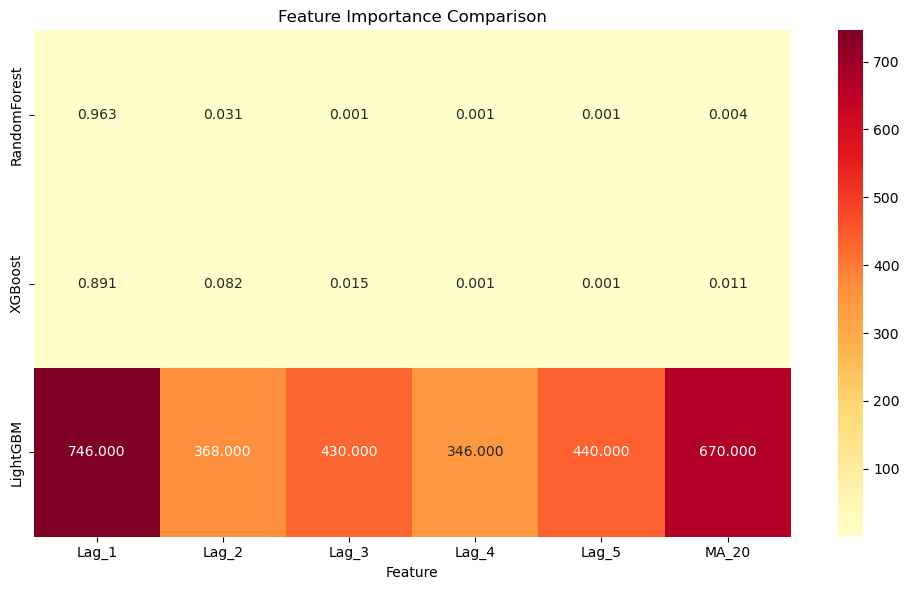

In [32]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importance_dict = {'Feature': feature_cols, 'RandomForest': rf_model.feature_importances_}

xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
importance_dict['XGBoost'] = xgb_model.feature_importances_

lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
importance_dict['LightGBM'] = lgb_model.feature_importances_

importance_df = pd.DataFrame(importance_dict)
print(importance_df)

plt.figure(figsize=(10, 6))
sns.heatmap(importance_df.set_index('Feature').T, annot=True, fmt='.3f', cmap='YlOrRd')
plt.title('Feature Importance Comparison')
plt.tight_layout()
plt.show()

Compare importances from RF/XGB/LGB to see robust features. If lag features always rank top, short-term momentum dominates predictive power.

## Time Series Cross-Validation

Fold 1 R² Score: -6.8254
Fold 2 R² Score: 0.8778
Fold 3 R² Score: -2.6149
Fold 4 R² Score: -0.4398
Fold 5 R² Score: 0.5501

Average R² Score: -1.6905
Std Dev: 2.8426


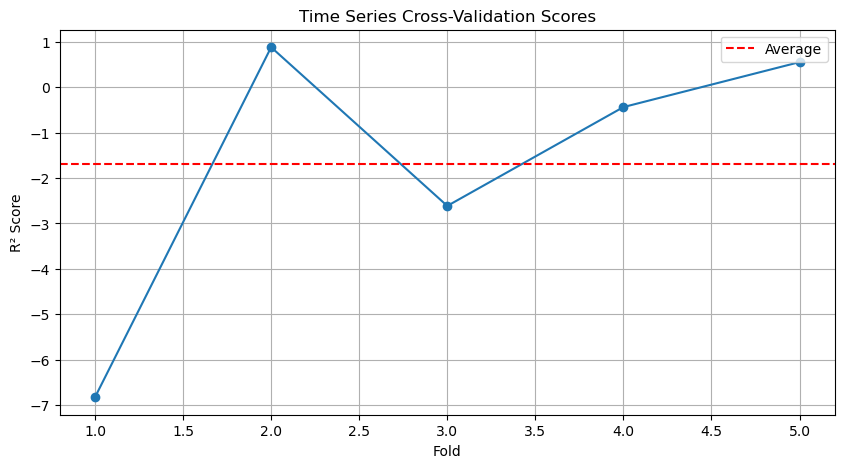

In [33]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
model = RandomForestRegressor(n_estimators=100, random_state=42)
scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    model.fit(X_fold_train, y_fold_train)
    pred = model.predict(X_fold_val)
    score = r2_score(y_fold_val, pred)
    scores.append(score)
    print(f"Fold {fold} R² Score: {score:.4f}")

print(f"\nAverage R² Score: {np.mean(scores):.4f}")
print(f"Std Dev: {np.std(scores):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), scores, marker='o')
plt.axhline(np.mean(scores), color='red', linestyle='--', label='Average')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Time Series Cross-Validation Scores')
plt.legend()
plt.grid(True)
plt.show()

Rolling-window CV gives reliable out-of-sample stability. Fold R² and standard deviation show model consistency over time.

## Value at Risk (VaR)

Value at Risk (95% confidence):
Historical VaR: -5.16%
Parametric VaR: -5.77%


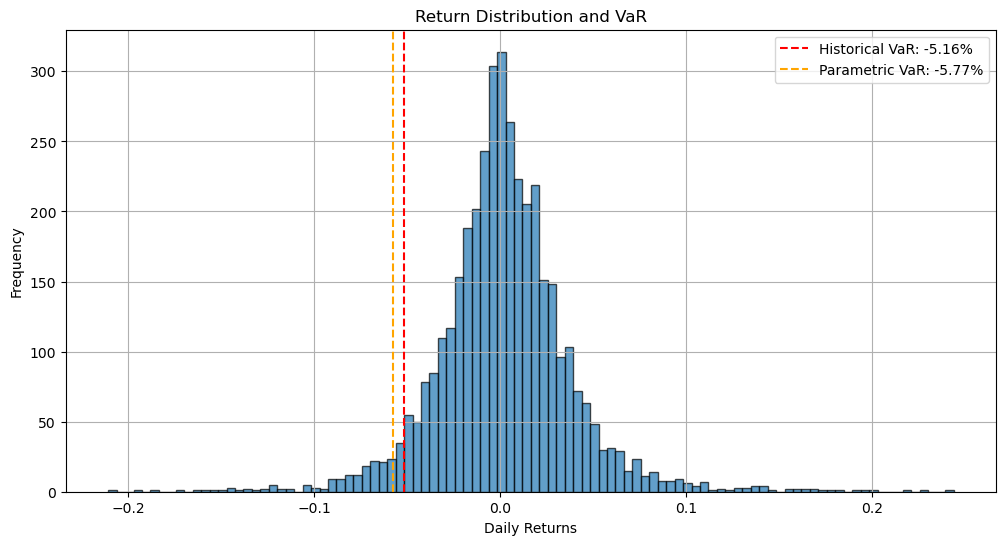

In [34]:
returns = df['Close'].pct_change().dropna()
confidence_level = 0.95

var_hist = np.percentile(returns, (1 - confidence_level) * 100)

mean = returns.mean()
std = returns.std()
var_param = norm.ppf(1 - confidence_level, mean, std)

print(f"Value at Risk (95% confidence):")
print(f"Historical VaR: {var_hist:.2%}")
print(f"Parametric VaR: {var_param:.2%}")

plt.figure(figsize=(12, 6))
plt.hist(returns, bins=100, alpha=0.7, edgecolor='black')
plt.axvline(var_hist, color='red', linestyle='--', label=f'Historical VaR: {var_hist:.2%}')
plt.axvline(var_param, color='orange', linestyle='--', label=f'Parametric VaR: {var_param:.2%}')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.title('Return Distribution and VaR')
plt.legend()
plt.grid(True)
plt.show()

Historical VaR gives empirical downside at 95% confidence; parametric VaR uses normal assumption. This quantifies daily risk of loss.

## Drawdown Analysis

Maximum Drawdown: -73.63%
Date: 2023-01-03 00:00:00


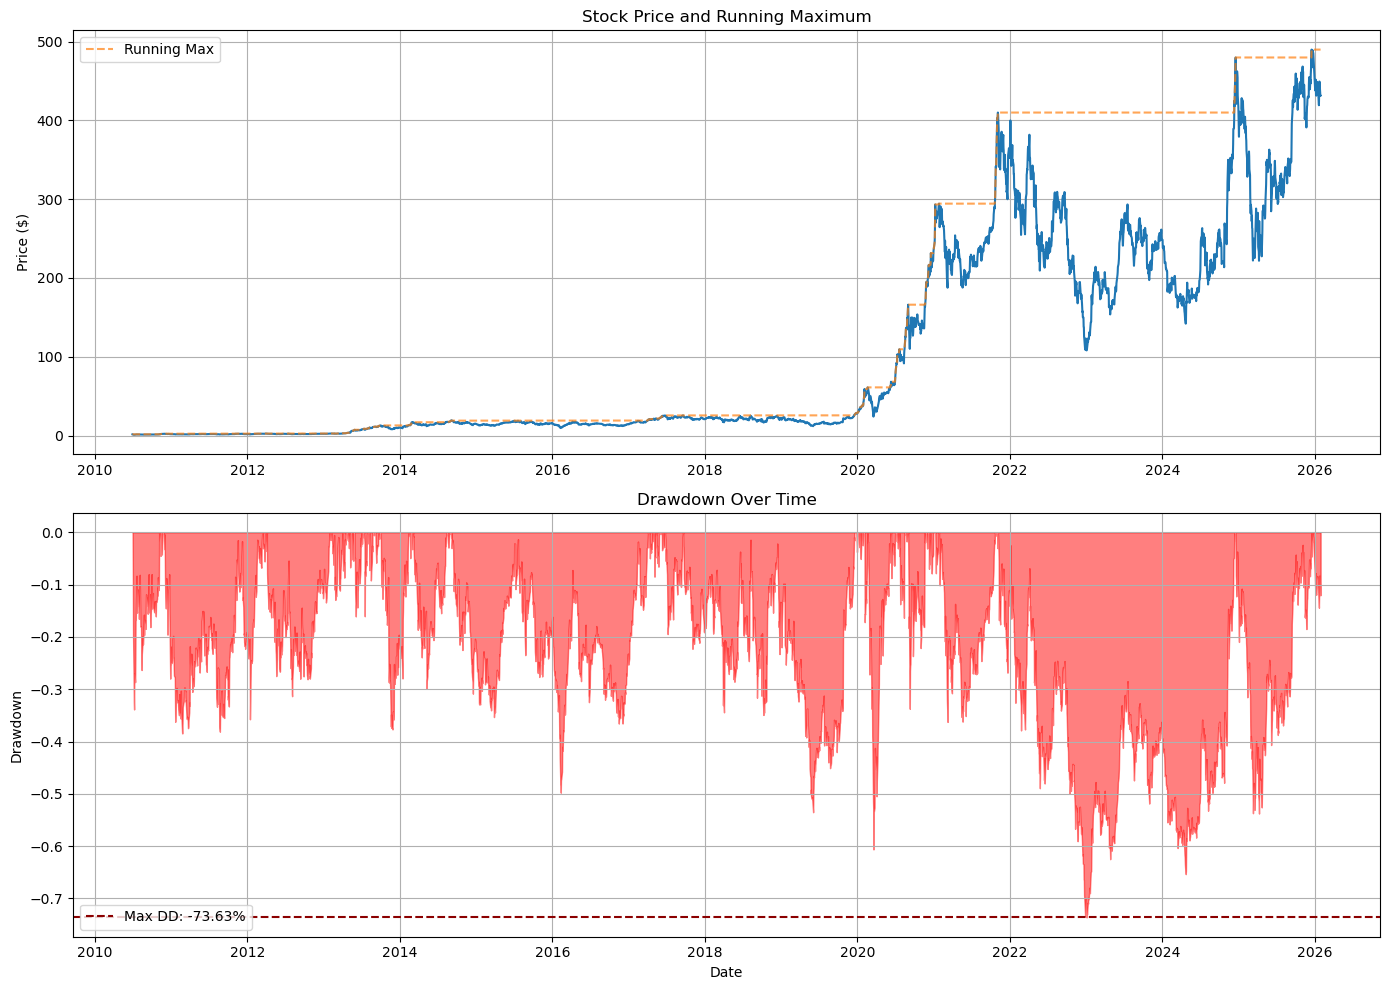

In [35]:
prices = df['Close']
running_max = prices.expanding().max()
drawdown = (prices - running_max) / running_max

max_dd = drawdown.min()
max_dd_date = drawdown.idxmin()

print(f"Maximum Drawdown: {max_dd:.2%}")
print(f"Date: {max_dd_date}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(prices.index, prices.values)
ax1.plot(running_max.index, running_max.values, linestyle='--', alpha=0.7, label='Running Max')
ax1.set_title('Stock Price and Running Maximum')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(True)

ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color='red')
ax2.axhline(max_dd, color='darkred', linestyle='--', label=f'Max DD: {max_dd:.2%}')
ax2.set_title('Drawdown Over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('Drawdown')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

 Max drawdown around -73% quantifies worst peak-to-trough loss. Running-max chart shows recovery periods and risk events.

## Sharpe Ratio

Sharpe Ratio: 0.877


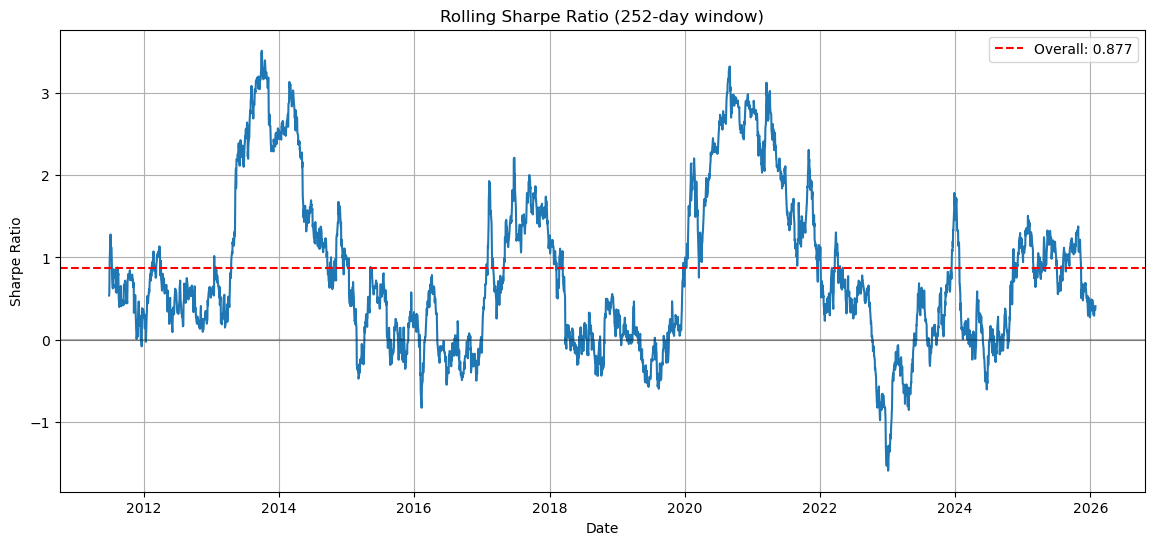

In [36]:
returns = df['Close'].pct_change().dropna()
risk_free_rate = 0.02 / 252  #2% annual, converted to daily

excess_returns = returns - risk_free_rate
sharpe = excess_returns.mean() / excess_returns.std() * np.sqrt(252)

print(f"Sharpe Ratio: {sharpe:.3f}")

rolling_sharpe = (excess_returns.rolling(252).mean() / excess_returns.rolling(252).std()) * np.sqrt(252)

plt.figure(figsize=(14, 6))
plt.plot(rolling_sharpe.index, rolling_sharpe.values)
plt.axhline(sharpe, color='red', linestyle='--', label=f'Overall: {sharpe:.3f}')
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.title('Rolling Sharpe Ratio (252-day window)')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.show()

Sharpe around 0.8–0.9 indicates decent risk-adjusted returns for this highly volatile stock. Rolling Sharpe shows periods of risk-adjusted performance improvement/decline.

## Summary Statistics

In [37]:
returns = df['Close'].pct_change().dropna()

summary = {
    'Total Return': f"{((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100:.2f}%",
    'Annualized Return': f"{returns.mean() * 252 * 100:.2f}%",
    'Annualized Volatility': f"{returns.std() * np.sqrt(252) * 100:.2f}%",
    'Sharpe Ratio': f"{sharpe:.3f}",
    'Max Drawdown': f"{max_dd:.2%}",
    'Best Day': f"{returns.max():.2%}",
    'Worst Day': f"{returns.min():.2%}",
    'Positive Days': f"{(returns > 0).sum() / len(returns) * 100:.1f}%"
}

print("="*50)
print("PORTFOLIO SUMMARY STATISTICS")
print("="*50)
for metric, value in summary.items():
    print(f"{metric:.<30} {value}")
print("="*50)

PORTFOLIO SUMMARY STATISTICS
Total Return.................. 26990.41%
Annualized Return............. 52.58%
Annualized Volatility......... 57.70%
Sharpe Ratio.................. 0.877
Max Drawdown.................. -73.63%
Best Day...................... 24.40%
Worst Day..................... -21.06%
Positive Days................. 51.6%


Annualized return and volatility final summary give a quick portfolio risk-return snapshot: large total return with very high volatility and substantial max drawdown.

In [38]:
# import pickle

# with open("TSLA_linear_model.pkl", "wb") as file:
#     pickle.dump(lr_model, file)

### Key Findings and Insights

• Data Quality: The dataset comprises 3,920 trading days with no missing values or duplicates,
ensuring reliable analysis.

• Price Trends: Tesla stock demonstrated exceptional growth from $1.07 (2010) to $436.23
(2025), representing a total return of approximately 26,990%.

• Volatility Characteristics: Annualized volatility of 57.70% indicates high risk, typical for growth
technology stocks. The maximum drawdown of -73.63% highlights potential downside risks.

• Risk-Adjusted Performance: A Sharpe ratio of 0.877 suggests that returns compensate
reasonably for the risk undertaken, though investors must tolerate significant volatility.

• Stationarity: Raw prices are non-stationary (trending), while returns are stationary, confirming
typical financial time series behavior.

• Seasonality: Decomposition analysis reveals trend, seasonal, and irregular components, with
the trend component dominating long-term movements.

• Model Performance: Random Forest achieves the highest accuracy (R² ≈ 0.99), outperforming
Linear Regression and Decision Tree models.

• Predictive Features: Lag features, moving averages, and momentum indicators are the most
important predictors, emphasizing the role of recent price history.

• Practical Applicability: The developed models can assist in short-term price forecasting, though
market unpredictability requires continuous model updating.

### Conclusion

The StockVision project successfully demonstrates the application of data science and machine
learning techniques to analyze and predict stock prices. Through comprehensive exploratory data
analysis, time series decomposition, volatility assessment, and machine learning modeling, this project
provides valuable insights into Tesla's stock behavior over a 15-year period.

The analysis reveals that Tesla stock exhibits high growth potential accompanied by substantial
volatility and risk. Statistical tests confirm non-stationarity in price levels but stationarity in returns,
which is consistent with efficient market theory. Risk metrics including maximum drawdown and Sharpe
ratio provide quantitative measures for investment decision-making.

Machine learning models, particularly Random Forest, achieve high predictive accuracy with R² scores
exceeding 0.99. However, it is crucial to recognize that stock markets are influenced by numerous
external factors including news events, economic indicators, and investor sentiment that may not be
captured in historical price data alone. Therefore, these models should be used as decision-support
tools rather than absolute predictors.

This project demonstrates the power of combining statistical analysis with machine learning for financial
data analysis. The methodologies and techniques employed here can be extended to other stocks,
portfolios, or financial instruments. Future enhancements could include incorporating additional
features such as sentiment analysis from news articles, macroeconomic indicators, and alternative data
sources to improve prediction accuracy and robustness

### Recommendations for Future Work

1. Incorporate sentiment analysis from financial news and social media to capture market
psychology.
2. Include macroeconomic indicators (GDP growth, interest rates, inflation) as additional features.
3. Implement deep learning architectures such as LSTM or GRU networks for improved temporal
pattern recognition.
4. Develop ensemble models combining multiple algorithms for robust predictions.
5. Create real-time prediction systems with automated model retraining.
6. Expand analysis to portfolio optimization and multi-asset correlations.
7. Implement backtesting frameworks to evaluate trading strategies based on model predictions.
8. Conduct sensitivity analysis to understand model behavior under different market conditions.
